# Extreme Precipitation Percentile Map

## Purpose
This notebook plots the **extreme precipitation** percentile maps across multiple observational and global storm-resolving model (GSRM) sources.

## Input Data
1-hourly extreme precipitation percentile thresholds on a HEALPix grid (zoom `hp8`; `hp9` is a switch in the config cell), one NetCDF file per source (the six sources and the second observational product GSMaPv8),
read from the CFS folder, which is identical file by file to `/pscratch/sd/w/wcmca1/hackathon/extreme_precip_1h/`:
```
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h/<source>_precip_percentiles_1h_<zoom>_v1.nc
```
These files are generated by:
- **Python script:** `waccem/gsrm_cooccurrencefeature/scripts/calc_extreme_precip_thresholds_1h.py`
- **Bash script** (processes all sources): `waccem/gsrm_cooccurrencefeature/scripts/run_all_extreme_precip_thresholds_1h.sh` (Slurm: `waccem/gsrm_cooccurrencefeature/slurm/slurm_extreme_precip_thresholds_1h.sh`)

The thresholds are computed from the sources' hourly precipitation; they were not part of the 2026-09 re-processing of Analyses 1 and 2 (the 6-hourly thresholds of `plot_extreme_rain_threshold_map.ipynb` were).

**Sources:** OBS (IMERGv7), SCREAM (m1), ICON (m2), NICAM (m3), UM (m4), CASESM2 (m5)

## Plots Generated
| Figure | Description | Output File |
|--------|-------------|-------------|
| Global map | Extreme precip values (6-panel, one per source) | `globalmap_extreme_precip_threshold_zoom<8 or 9>_<P95>.pdf` |
| Observation interannual variability | P95 threshold of the two observational products (top) and its interannual interquartile range (bottom) | `globalmap_extreme_precip_threshold_zoom<8 or 9>_<P95>_obs_IQR.pdf` |

Output figures are saved to: `/global/cfs/cdirs/m1867/zfeng/hk25/figures_extremerain_1h/`

In [1]:
import glob
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

In [2]:
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/extreme_precip_1h/'
rootdir = '/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h/'
name_map = {
    'obs1': 'IMERGv7',
    'obs2': 'GSMaPv8',
    'm1': 'scream',
    'm2': 'icon_d3hp003',
    'm3': 'nicam_gl11',
    'm4': 'um_glm_n2560_RAL3p3',
    'm5': 'casesm2_10km_nocumulus',
}
name_map_plot = {
    'obs1': 'IMERG',
    'obs2': 'GSMaP',
    'm1': 'SCREAM',
    'm2': 'ICON',
    'm3': 'NICAM',
    'm4': 'UM',
    'm5': 'CAS',
}

# Healpix zoom level
# zoom = 'hp9'
zoom = 'hp8'

# Input filenames
filenames = {key:glob.glob(f"{rootdir}/{value}_precip_percentiles_1h_{zoom}_v1.nc")[0] for key,value in name_map.items()}

landmaskfile = f'/global/cfs/cdirs/m4581/gsharing/hackathon/scream-cess-healpix/scream2D_hrly_topo_{zoom}_v7.zarr'

# gsmapfile = f'/pscratch/sd/w/wcmca1/hackathon/extreme_precip_1h/GSMaPv8_precip_percentiles_1h_{zoom}_2020_v1.1.nc'

figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_extremerain_1h/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_extremerain_1h/


### Check if input files exist

In [3]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h//IMERGv7_precip_percentiles_1h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h//GSMaPv8_precip_percentiles_1h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h//scream_precip_percentiles_1h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h//icon_d3hp003_precip_percentiles_1h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h//nicam_gl11_precip_percentiles_1h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h//um_glm_n2560_RAL3p3_precip_percentiles_1h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip_1h//casesm2_10km_nocumulus_precip_percentiles_1h_hp8_v1.nc: True


In [4]:
# Read in landmask file
dstop = xr.open_dataset(landmaskfile)
ter = dstop.ELEV
landfrac = dstop.LANDFRAC
dstop

<xarray.Dataset> Size: 13MB
Dimensions:   (cell: 786432, crs: 0)
Coordinates:
  * crs       (crs) float64 0B 
Dimensions without coordinates: cell
Data variables:
    ELEV      (cell) float32 3MB ...
    LANDFRAC  (cell) float32 3MB ...
    lat       (cell) float32 3MB ...
    lon       (cell) float32 3MB ...
Attributes:
    NCO:                        netCDF Operators version 4.9.8-alpha01 (Homep...
    history:                    Fri Jun 11 12:26:48 2021: ncks -A USGS-gtopo3...
    history_of_appended_files:  Fri Jun 11 12:26:48 2021: Appended file USGS-...
    source:                     USGS 30-sec dataset binned to ncube3000 (cube...
    title:                      30-second USGS topo data

Text(0.5, 1.0, 'Land Fraction Map')

<Figure size 640x480 with 0 Axes>

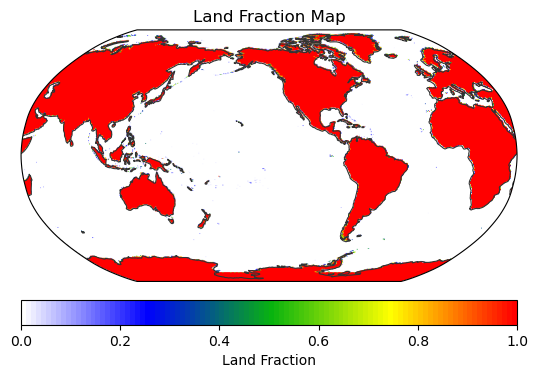

In [5]:
im = egh.healpix_show(landfrac,  cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Land Fraction')
plt.title('Land Fraction Map')

In [6]:
# # Read in GSMaP file (for snow probability)
# dsgsmap = xr.open_dataset(gsmapfile)
# dsgsmap
dstop.crs.attrs

{'grid_mapping_name': 'healpix', 'healpix_nside': 256, 'healpix_order': 'nest'}

In [7]:
# im = egh.healpix_show(dsgsmap.snow_probability,  cmap=cmaps.WhBlGrYeRe)
# plt.colorbar(im, orientation='horizontal', pad=0.05, label='Snow Probability (%)')
# plt.title('GSMaPv8 Snow Probability (2020)')

### Helper function to standardize lat/lon coordinates

When combining files from different sources, lat/lon coordinates may have different orderings even though they use the same HEALPix grid. This causes xarray to create 2D coordinates `(source, cell)` instead of 1D `(cell)`.

Solution: Use a reference landmask file to provide standardized lat/lon coordinates for all sources.

In [8]:
def standardize_healpix_coords(ds, reference_lat, reference_lon):
    """
    Replace lat/lon coordinates with standardized reference coordinates.
    
    This fixes the issue where different sources have the same HEALPix cells
    but with different lat/lon orderings, causing xarray to create 2D 
    coordinates (source, cell) instead of 1D (cell) when combining datasets.
    
    Parameters:
    -----------
    ds : xr.Dataset
        Dataset with lat/lon coordinates that may be in different order
    reference_lat : xr.DataArray
        Reference latitude coordinate (cell,)
    reference_lon : xr.DataArray
        Reference longitude coordinate (cell,)
    
    Returns:
    --------
    xr.Dataset with standardized lat/lon coordinates
    """
    # Drop existing lat/lon coordinates
    ds = ds.drop_vars(['lat', 'lon'], errors='ignore')
    
    # Assign standard coordinates
    ds = ds.assign_coords({
        'lat': reference_lat,
        'lon': reference_lon
    })
    
    return ds


# Load reference coordinates from landmask file
print("Loading reference HEALPix coordinates from landmask file...")
ds_ref = xr.open_dataset(landmaskfile)
reference_lat = ds_ref.lat
reference_lon = ds_ref.lon
print(f"✅ Reference coordinates loaded: {len(reference_lat)} cells")

Loading reference HEALPix coordinates from landmask file...
✅ Reference coordinates loaded: 786432 cells


### Helper function to standardize lat/lon coordinates

When combining files from different sources, lat/lon coordinates may have different orderings even though they use the same HEALPix grid. This causes xarray to create 2D coordinates `(source, cell)` instead of 1D `(cell)`.

Solution: Use a reference landmask file to provide standardized lat/lon coordinates for all sources.

In [9]:
# def standardize_healpix_coords(ds, reference_lat, reference_lon):
#     """
#     Replace lat/lon coordinates with standardized reference coordinates.
    
#     This fixes the issue where different sources have the same HEALPix cells
#     but with different lat/lon orderings, causing xarray to create 2D 
#     coordinates (source, cell) instead of 1D (cell) when combining datasets.
    
#     Parameters:
#     -----------
#     ds : xr.Dataset
#         Dataset with lat/lon coordinates that may be in different order
#     reference_lat : xr.DataArray
#         Reference latitude coordinate (cell,)
#     reference_lon : xr.DataArray
#         Reference longitude coordinate (cell,)
    
#     Returns:
#     --------
#     xr.Dataset with standardized lat/lon coordinates
#     """
#     # Drop existing lat/lon coordinates
#     ds = ds.drop_vars(['lat', 'lon'], errors='ignore')
    
#     # Assign standard coordinates
#     ds = ds.assign_coords({
#         'lat': reference_lat,
#         'lon': reference_lon
#     })
    
#     return ds


# # Load reference coordinates from landmask file
# print("Loading reference HEALPix coordinates from landmask file...")
# ds_ref = xr.open_dataset(landmaskfile)
# reference_lat = ds_ref.lat
# reference_lon = ds_ref.lon
# print(f"✅ Reference coordinates loaded: {len(reference_lat)} cells")

## Read and combine all sources to a single DataSet

**Important:** When combining sources, we standardize lat/lon coordinates using a reference to ensure they remain 1D `(cell)` rather than becoming 2D `(source, cell)`. See explanation cells above for details.

In [10]:
drop_vars = []
# Read and standardize each file individually, then combine
print("Reading and standardizing coordinates for each source...")
datasets = []
years_dict = {}
for key, filepath in filenames.items():
    print(f"  {key}: {os.path.basename(filepath)}")
    ds_single = xr.open_dataset(filepath, drop_variables=drop_vars)
    # Standardize lat/lon coordinates to match reference
    ds_single = standardize_healpix_coords(ds_single, reference_lat, reference_lon)
    datasets.append(ds_single)
    if 'year' in ds_single.coords:
        years_dict[key] = ds_single.year.values
    else:
        years_dict[key] = None

# Combine with source dimension
ds = xr.concat(datasets, dim='source', coords='minimal')
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())

# Load lat/lon coordinates in memory
hp_lat = ds.lat.load()
hp_lon = ds.lon.load()

print(f"\n✅ Combined dataset:")
print(f"   Sources: {list(ds.source.values)}")
print(f"   Lat dimensions: {ds.lat.dims}, shape: {ds.lat.shape}")
print(f"   Lon dimensions: {ds.lon.dims}, shape: {ds.lon.shape}")
ds

Reading and standardizing coordinates for each source...
  obs1: IMERGv7_precip_percentiles_1h_hp8_v1.nc
  obs2: GSMaPv8_precip_percentiles_1h_hp8_v1.nc


  m1: scream_precip_percentiles_1h_hp8_v1.nc
  m2: icon_d3hp003_precip_percentiles_1h_hp8_v1.nc
  m3: nicam_gl11_precip_percentiles_1h_hp8_v1.nc
  m4: um_glm_n2560_RAL3p3_precip_percentiles_1h_hp8_v1.nc
  m5: casesm2_10km_nocumulus_precip_percentiles_1h_hp8_v1.nc



✅ Combined dataset:
   Sources: [np.str_('obs1'), np.str_('obs2'), np.str_('m1'), np.str_('m2'), np.str_('m3'), np.str_('m4'), np.str_('m5')]
   Lat dimensions: ('cell',), shape: (786432,)
   Lon dimensions: ('cell',), shape: (786432,)


<xarray.Dataset> Size: 648MB
Dimensions:        (source: 7, cell: 786432, year: 24)
Coordinates:
  * cell           (cell) int32 3MB 0 1 2 3 4 ... 786428 786429 786430 786431
  * year           (year) int32 96B 2001 2002 2003 2004 ... 2021 2022 2023 2024
    crs            int64 8B 0
    lat            (cell) float32 3MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon            (cell) float32 3MB 45.02 45.2 44.85 ... 315.2 314.8 315.0
  * source         (source) <U4 112B 'obs1' 'obs2' 'm1' 'm2' 'm3' 'm4' 'm5'
Data variables:
    pr_p95         (source, cell) float32 22MB 2.65 2.838 2.737 ... 4.382 4.262
    pr_annual_p95  (source, year, cell) float32 528MB 7.929 5.796 ... nan nan
    pr_q25_p95     (source, cell) float32 22MB 2.044 1.98 2.026 ... nan nan nan
    pr_q75_p95     (source, cell) float32 22MB 3.163 3.621 3.851 ... nan nan nan
    pr_iqr_p95     (source, cell) float32 22MB 1.119 1.641 1.825 ... nan nan nan
    pr_p99         (source, cell) float32 22MB nan nan nan ... 13.86 14.36 15.97
Attributes: (12/15)
    Title:                   Precipitation percentiles at different time scales
    contact:                 Zhe Feng, zhe.feng@pnnl.gov
    source_name:             IMERGv7
    start_date:              2001-01-01T00:00
    end_date:                2024-12-31T23:59
    created_on:              Fri Aug  7 02:33:11 2026
    ...                      ...
    quantile_method:         linear
    min_precip_threshold:    0.1 mm/h
    threshold_note:          Precipitation below 0.1 mm/h excluded from perce...
    annual_years:            2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, ...
    n_annual_years:          24
    min_year_coverage_days:  300

In [11]:
years_dict

{'obs1': array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
        2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
        2023, 2024], dtype=int32),
 'obs2': array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
        2021, 2022, 2023, 2024], dtype=int32),
 'm1': None,
 'm2': None,
 'm3': None,
 'm4': None,
 'm5': None}

In [12]:
year_range_obs1 = f"{np.min(years_dict['obs1'])}-{np.max(years_dict['obs1'])}"
year_range_obs2 = f"{np.min(years_dict['obs2'])}-{np.max(years_dict['obs2'])}"
year_range_obs1, year_range_obs2

('2001-2024', '2010-2024')

In [13]:
zoom_level = ds.attrs['zoom_level']
print(zoom_level)

8


## Filter DataSet in the Polar Region (GSMaP)

In [14]:
# Filter obs2 (GSMaP) suspicious high values in the Arctic ocean region.
# This is based on visual inspection of the GSMaP data, which shows anomalously
# high precipitation values (large areas of P95 > 6 mm/h) in the Arctic ocean
# that are not present in IMERG or any of the models — likely a passive-microwave
# retrieval artifact over sea ice / open Arctic ocean.

arctic_lat_thresh = 75   # deg N, defines the Arctic ocean region
max_landfrac = 0.5       # exclude only fully-land cells (landfrac == 1); keep ocean + mixed cells

# Arctic ocean mask: True where a cell is in the Arctic AND not fully land
arctic_ocean_mask = (ds.lat > arctic_lat_thresh) & (landfrac < max_landfrac)

# Restrict the mask to source == 'obs2' only; broadcasts to (source, cell)
is_obs2 = ds['source'] == 'obs2'
remove_mask = is_obs2 & arctic_ocean_mask

n_flagged = int(arctic_ocean_mask.sum())
n_masked = int((remove_mask & ds['pr_p95'].notnull()).sum())
print(f"Arctic ocean mask (lat > {arctic_lat_thresh}, landfrac < {max_landfrac}): {n_flagged} cells")
print(f"Masking {n_masked} obs2 (GSMaP) cells with suspicious values to NaN; all other sources left unchanged")

# ds.where() masks matching (source, cell) combinations to NaN across every
# variable in the dataset (pr_p95, pr_p99, pr_iqr_p95, pr_annual_p95, ...);
# cells outside the mask and all sources other than obs2 are untouched
ds = ds.where(~remove_mask)
ds

Arctic ocean mask (lat > 75, landfrac < 0.5): 10954 cells
Masking 10224 obs2 (GSMaP) cells with suspicious values to NaN; all other sources left unchanged


<xarray.Dataset> Size: 648MB
Dimensions:        (source: 7, cell: 786432, year: 24)
Coordinates:
  * cell           (cell) int32 3MB 0 1 2 3 4 ... 786428 786429 786430 786431
  * year           (year) int32 96B 2001 2002 2003 2004 ... 2021 2022 2023 2024
    crs            int64 8B 0
    lat            (cell) float32 3MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon            (cell) float32 3MB 45.02 45.2 44.85 ... 315.2 314.8 315.0
  * source         (source) <U4 112B 'obs1' 'obs2' 'm1' 'm2' 'm3' 'm4' 'm5'
Data variables:
    pr_p95         (source, cell) float32 22MB 2.65 2.838 2.737 ... 4.382 4.262
    pr_annual_p95  (source, year, cell) float32 528MB 7.929 5.796 ... nan nan
    pr_q25_p95     (source, cell) float32 22MB 2.044 1.98 2.026 ... nan nan nan
    pr_q75_p95     (source, cell) float32 22MB 3.163 3.621 3.851 ... nan nan nan
    pr_iqr_p95     (source, cell) float32 22MB 1.119 1.641 1.825 ... nan nan nan
    pr_p99         (source, cell) float32 22MB nan nan nan ... 13.86 14.36 15.97
Attributes: (12/15)
    Title:                   Precipitation percentiles at different time scales
    contact:                 Zhe Feng, zhe.feng@pnnl.gov
    source_name:             IMERGv7
    start_date:              2001-01-01T00:00
    end_date:                2024-12-31T23:59
    created_on:              Fri Aug  7 02:33:11 2026
    ...                      ...
    quantile_method:         linear
    min_precip_threshold:    0.1 mm/h
    threshold_note:          Precipitation below 0.1 mm/h excluded from perce...
    annual_years:            2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, ...
    n_annual_years:          24
    min_year_coverage_days:  300

<Figure size 640x480 with 0 Axes>

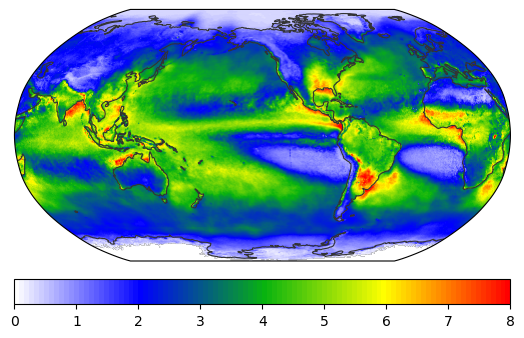

In [15]:
im = egh.healpix_show(ds.pr_p95.sel(source='obs1'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

<Figure size 640x480 with 0 Axes>

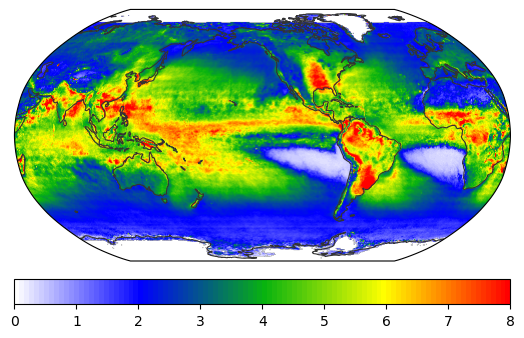

In [16]:
im = egh.healpix_show(ds.pr_p95.sel(source='obs2'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

<Figure size 640x480 with 0 Axes>

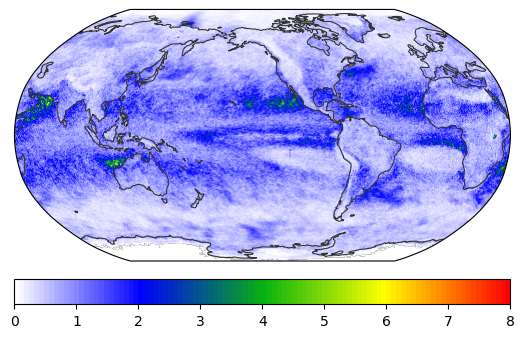

In [17]:
im = egh.healpix_show(ds.pr_iqr_p95.sel(source='obs1'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

<Figure size 640x480 with 0 Axes>

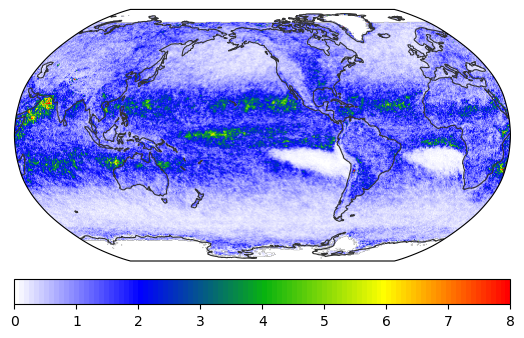

In [18]:
im = egh.healpix_show(ds.pr_iqr_p95.sel(source='obs2'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

In [19]:
ds.pr_p95.sel(source='m5').max()

<xarray.DataArray 'pr_p95' ()> Size: 4B
array(25.772343, dtype=float32)
Coordinates:
    crs      int64 8B 0
    source   <U4 16B 'm5'

<Figure size 640x480 with 0 Axes>

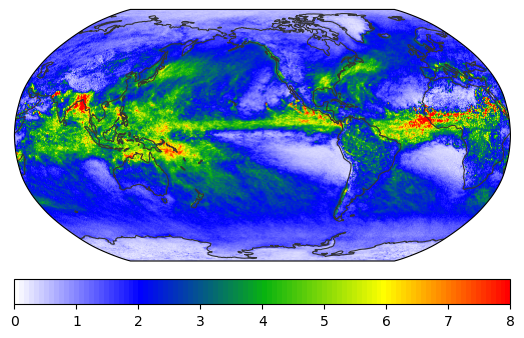

In [20]:
im = egh.healpix_show(ds.pr_p95.sel(source='m5'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

## Function to plot contribution fraction maps

In [21]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [22]:
def plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname, 
                  min_thresh=None, wspace=None, hspace=None, oob_colors=None, 
                  contourf=False, figsize=None, fontsize=None, cb_fontsize=None, 
                  show_gridlines=False, figtitle=None, dpi=200, lat_lines=None):
    """
    Plot a grid of maps with flexible dimensions
    
    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot, dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    levels, colormaps, etc.: can be single values applied to all panels or lists of lists matching da_list
    lat_lines : list or None
        List of latitude values to plot as horizontal lines (e.g., [-20, 20] for tropics)
    """
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0
    
    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list (like levels=[1,2,3,5,7,10]), use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param
    
    # Ensure all parameters have proper grid format
    colormaps = ensure_grid_format(colormaps, "colormaps")
    levels = ensure_grid_format(levels, "levels")
    cbticks = ensure_grid_format(cbticks, "cbticks")
    
    mpl.rcParams['font.size'] = fontsize
    map_extent = [0, 360, -60, 60]
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cf.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cf.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], 
                                         height_ratios=h_ratios, width_ratios=w_ratios, 
                                         wspace=wspace, hspace=hspace)
    
    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:
            
                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                
                # Add title
                flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))           
                
                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                
                # Setup colormap
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row][col]))
                
                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])
                
                # Create color normalization
                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
                
                # Plot data
                if not contourf:
                    cf1 = egh.healpix_show(Var, ax=ax, cmap=cmap, norm=norm, zorder=2)            
                else:
                    cf1 = egh.healpix_contour(Var, ax=ax, norm=norm, cmap=cmap, transform=data_proj, zorder=2)
                
                # Add gridlines
                if show_gridlines:
                    gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)

                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                            transform=data_proj, zorder=4, alpha=0.8)
    
    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label=cblabels, ticks=cbticks[row][col], 
                           orientation='vertical', extend='both')
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold')
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

✅ Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_extremerain_1h/globalmap_extreme_precip_threshold_zoom8_P95.pdf


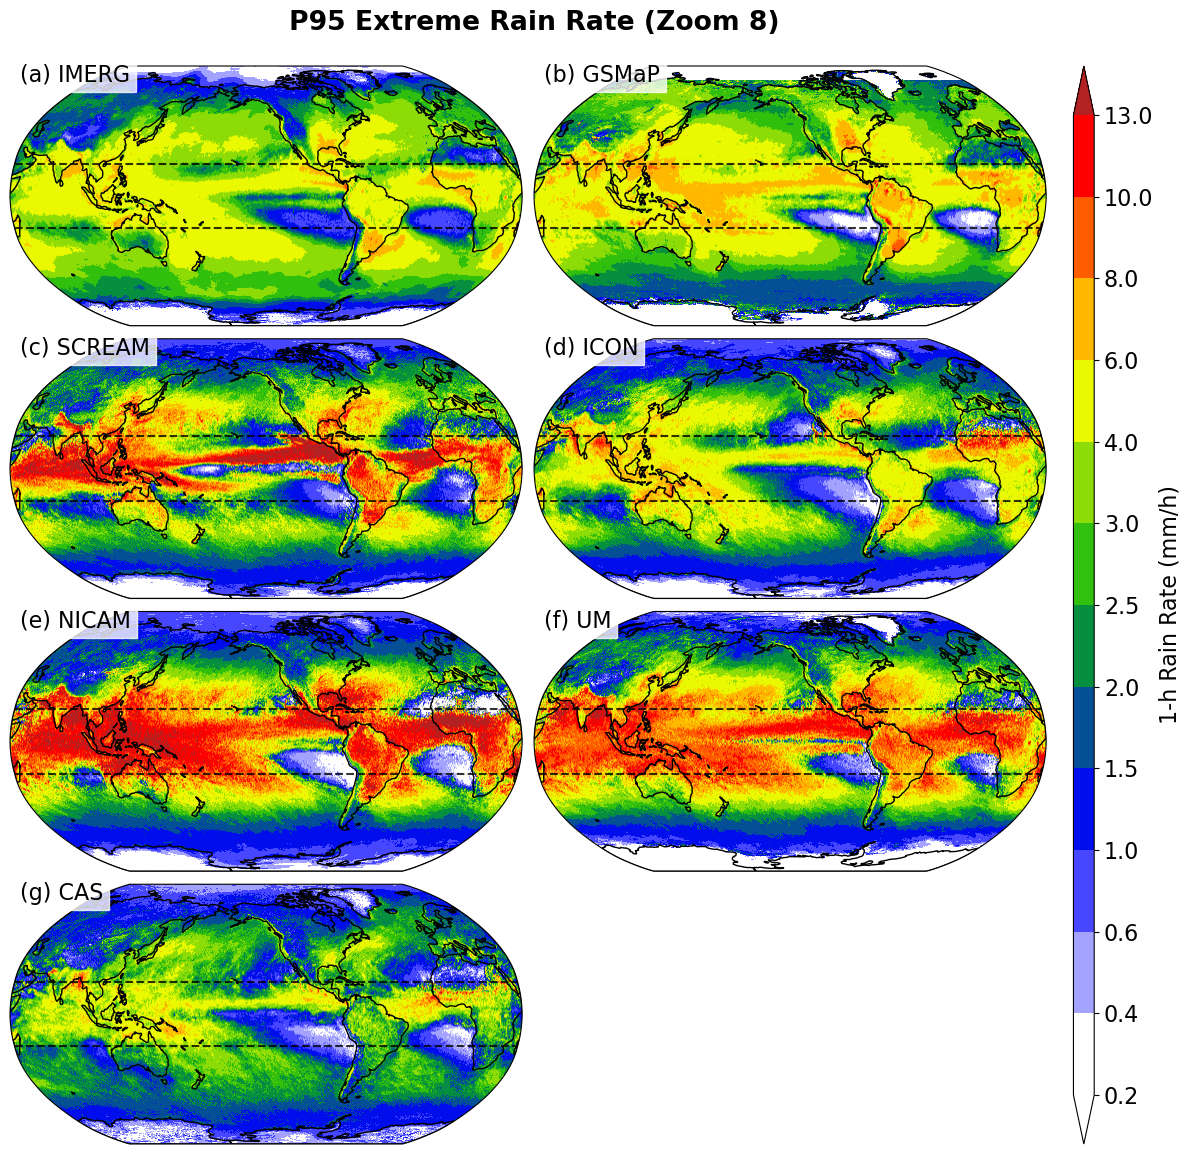

In [23]:
tropics_lat = [-20, 20]
extreme_percentile = 'p95'
VAR = f'pr_{extreme_percentile}'

# Create 2D lists for data and titles
da_list = [
    [ds[VAR].sel(source='obs1'), ds[VAR].sel(source='obs2')],
    [ds[VAR].sel(source='m1'), ds[VAR].sel(source='m2')],
    [ds[VAR].sel(source='m3'), ds[VAR].sel(source='m4')],
    [ds[VAR].sel(source='m5'), None],
]
titles = [
    [f"(a) {name_map_plot['obs1']}", f"(b) {name_map_plot['obs2']}"],
    [f"(c) {name_map_plot['m1']}", f"(d) {name_map_plot['m2']}"],
    [f"(e) {name_map_plot['m3']}", f"(f) {name_map_plot['m4']}"],
    [f"(g) {name_map_plot['m5']}", ""]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 16
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = '1-h Rain Rate'
units = 'mm/h'
figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate (Zoom {zoom_level})'
lat_lines = tropics_lat

# Setup levels and colormap
# levels = [0.1,0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8,10]
levels = [0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8,10,13]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_extreme_precip_threshold_zoom{zoom_level}_{extreme_percentile.upper()}.pdf'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)
print(f"✅ Figure saved: {figname}")

✅ Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_extremerain_1h/globalmap_extreme_precip_threshold_zoom8_P95_obs_IQR.pdf


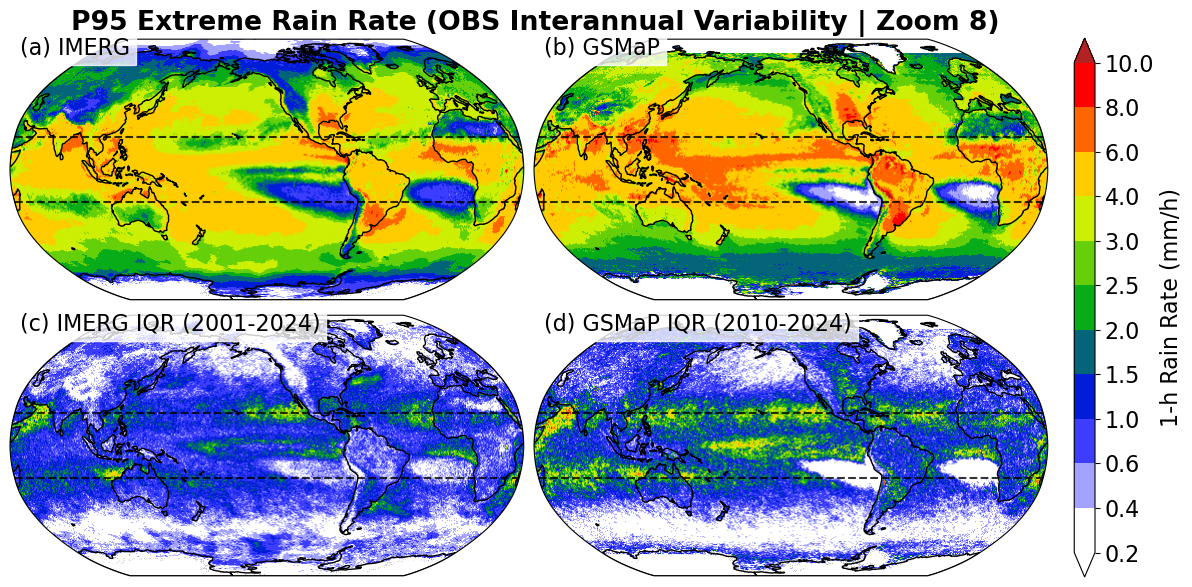

In [24]:
tropics_lat = [-20, 20]
extreme_percentile = 'p95'
VAR = f'pr_{extreme_percentile}'

# Create 2D lists for data and titles
da_list = [
    [ds[VAR].sel(source='obs1'), ds[VAR].sel(source='obs2')],
    [ds['pr_iqr_p95'].sel(source='obs1'), ds['pr_iqr_p95'].sel(source='obs2')],
]
titles = [
    [f"(a) {name_map_plot['obs1']}", f"(b) {name_map_plot['obs2']}"],
    [f"(c) {name_map_plot['obs1']} IQR ({year_range_obs1})", f"(d) {name_map_plot['obs2']} IQR ({year_range_obs2})"],
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 16
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = '1-h Rain Rate'
units = 'mm/h'
figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate (OBS Interannual Variability | Zoom {zoom_level})'
lat_lines = tropics_lat

# Setup levels and colormap
levels = [0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8,10]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_extreme_precip_threshold_zoom{zoom_level}_{extreme_percentile.upper()}_obs_IQR.pdf'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)
print(f"✅ Figure saved: {figname}")

In [25]:
# tropics_lat = [-20, 20]
# extreme_percentile = 'p95'
# VAR = f'pr_{extreme_percentile}'

# # Create 2D lists for data and titles
# da_list = [
#     [ds[VAR].sel(source='obs'), ds[VAR].sel(source='m1')],
#     [ds[VAR].sel(source='m2'), ds[VAR].sel(source='m3')],
#     [ds[VAR].sel(source='m4'), ds[VAR].sel(source='m5')],
# ]
# titles = [
#     [f"(a) {name_map_plot['obs']}", f"(b) {name_map_plot['m1']}"],
#     [f"(c) {name_map_plot['m2']}", f"(d) {name_map_plot['m3']}"],
#     [f"(e) {name_map_plot['m4']}", f"(f) {name_map_plot['m5']}"]
# ]

# # Setup grid parameters
# nrow = len(da_list)
# ncol = len(da_list[0]) if nrow > 0 else 1
# figwidth = 14
# height_ratio_per_panel = 0.5
# figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
# figsize = [figwidth, figheight]
# fontsize = 16
# cb_fontsize = 10
# wspace = 0.02
# hspace = 0.05
# varname1 = '1-h Rain Rate'
# units = 'mm/h'
# figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate'
# lat_lines = tropics_lat

# # Setup levels and colormap
# # levels = [0.1,0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8,10]
# levels = [0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8,10,13]
# min_thresh = None
# colormaps = cmaps.WhBlGrYeRe
# cbticks = levels
# oob_colors = {'over':'firebrick', 'under':'white'}
# cblabels = f'{varname1} ({units})'
# figname = f'{figdir}globalmap_extreme_precip_threshold_{extreme_percentile.upper()}.png'

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [26]:
# tropics_lat = [-20, 20]
# extreme_percentile = 'p99'
# VAR = f'pr_{extreme_percentile}'

# # Create 2D lists for data and titles
# da_list = [
#     [ds[VAR].sel(source='obs'), ds[VAR].sel(source='m1')],
#     [ds[VAR].sel(source='m2'), ds[VAR].sel(source='m3')],
#     [ds[VAR].sel(source='m4'), ds[VAR].sel(source='m5')],
# ]
# titles = [
#     [f"(a) {name_map_plot['obs']}", f"(b) {name_map_plot['m1']}"],
#     [f"(c) {name_map_plot['m2']}", f"(d) {name_map_plot['m3']}"],
#     [f"(e) {name_map_plot['m4']}", f"(f) {name_map_plot['m5']}"]
# ]

# # Setup grid parameters
# nrow = len(da_list)
# ncol = len(da_list[0]) if nrow > 0 else 1
# figwidth = 14
# height_ratio_per_panel = 0.5
# figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
# figsize = [figwidth, figheight]
# fontsize = 16
# cb_fontsize = 10
# wspace = 0.02
# hspace = 0.05
# varname1 = '1-h Rain Rate'
# units = 'mm/h'
# figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate'
# lat_lines = tropics_lat

# # Setup levels and colormap
# levels = [0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8,10,13,16,20,25]
# min_thresh = None
# colormaps = cmaps.WhBlGrYeRe
# cbticks = levels
# oob_colors = {'over':'firebrick', 'under':'white'}
# cblabels = f'{varname1} ({units})'
# figname = f'{figdir}globalmap_extreme_precip_threshold_{extreme_percentile.upper()}.png'

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, show_gridlines=False, dpi=200)